Recovery Value Score

In [ ]:
results["excepted_recovery_value"] = (
    results["recovery_probability"] *
    results['outstanding_balance']
)

In [ ]:
results_priority = results.sort_values(by = 'excepted_recovery_value',ascending=False)

In [ ]:
results_priority[
    ["recovery_probability",
     "outstanding_balance",
     "excepted_recovery_value"]
].head(10)

,recovery_probability,outstanding_balance,excepted_recovery_value
1756,0.999864,487835,487768.700974
1335,0.990649,485065,480529.324456
1981,0.999918,479868,479828.806807
1118,0.999254,472372,472019.485170
1431,0.999869,468906,468844.586107
1190,0.988720,464865,459621.301749
1675,0.999628,457973,457802.593568
1550,0.999993,454376,454372.805904
1100,0.999978,450634,450624.011287
1624,0.999162,443966,443593.862994


In [ ]:
results_priority.head(10)

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,...,employment_type_Self-employed,dpd_bucket_soft,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high,actual_recovery,recovery_probability,excepted_recovery_value
1756,41,487835,49963,8,3,0.000016,9.763925,0.071429,0,False,...,True,True,False,False,True,False,False,1,0.999864,487768.700974
1335,62,485065,59104,5,0,0.000010,8.206974,0.000000,1,False,...,True,False,True,False,True,False,False,1,0.990649,480529.324456
1981,43,479868,40316,9,4,0.000019,11.902669,0.090909,0,True,...,False,True,False,False,True,False,False,1,0.999918,479828.806807
1118,75,472372,121582,8,2,0.000017,3.885213,0.026316,1,True,...,True,False,True,False,False,True,False,1,0.999254,472019.485170
1431,44,468906,98768,9,1,0.000019,4.747550,0.022222,0,True,...,False,True,False,False,False,True,False,1,0.999869,468844.586107
1190,55,464865,148216,7,3,0.000015,3.136402,0.053571,0,False,...,True,True,False,False,False,True,False,1,0.988720,459621.301749
1675,74,457973,124433,8,4,0.000017,3.680479,0.053333,1,False,...,True,False,True,False,False,True,False,1,0.999628,457802.593568
1550,61,454376,63856,9,3,0.000020,7.115635,0.048387,1,False,...,False,False,True,False,True,False,False,1,0.999993,454372.805904
1100,63,450634,138028,9,5,0.000020,3.264801,0.078125,1,False,...,True,False,True,False,False,True,False,1,0.999978,450624.011287
1624,39,443966,83293,7,2,0.000016,5.330172,0.050000,0,False,...,True,True,False,False,False,True,False,1,0.999162,443593.862994


Model based prioritization

In [ ]:
top_model_accounts = results_priority.head(100)

In [ ]:
model_strategy_recovery = top_model_accounts["excepted_recovery_value"].sum()

print(round(model_strategy_recovery/10000000,2))

2.46


Random calling

In [ ]:
random_accounts = results.sample(100, random_state=42)

In [ ]:
random_strategy_recovery = random_accounts["excepted_recovery_value"].sum()

print(round(random_strategy_recovery/10000000,2))

0.78


In [ ]:
print("Model Strategy:", model_strategy_recovery)
print("Random Strategy:", random_strategy_recovery)
print("Improvement:", model_strategy_recovery - random_strategy_recovery)

Model Strategy: 24609484.606072303
Random Strategy: 7759663.971182068
Improvement: 16849820.634890236


In [ ]:
results_priority["cumlative_recovery"] = (
    results_priority["excepted_recovery_value"].cumsum()
)

In [ ]:
random_results = results.sample(frac=1,random_state=42)

In [ ]:
random_results["random_cumlative_recovery"] = (
    random_results["excepted_recovery_value"].cumsum()
)

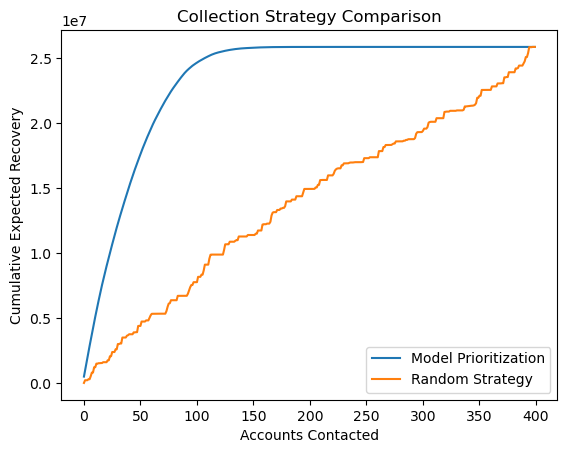

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(
    results_priority["cumlative_recovery"].values,
    label="Model Prioritization"
)

plt.plot(
    random_results["random_cumlative_recovery"].values,
    label="Random Strategy"
)

plt.xlabel("Accounts Contacted")
plt.ylabel("Cumulative Expected Recovery")
plt.title("Collection Strategy Comparison")

plt.legend()

plt.show()

Extract Logistic Coefficients

In [ ]:
import pandas as pd

coefficients = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(ascending=False)

print(coefficients)

dpd_bucket_hard                  3.859759e+00
previous_payments                1.774946e+00
employment_type_Self-employed    7.584186e-01
region_West                      6.283268e-01
income_segment_mid               5.119713e-01
high_risk_flag                   4.903938e-01
dpd_bucket_soft                  4.653777e-01
region_South                     1.889018e-01
employment_type_Salaried         1.551515e-01
payment_ratio                    4.076729e-05
outstanding_balance              9.802551e-08
income_segment_high              0.000000e+00
customer_income                 -7.370344e-06
region_North                    -1.908056e-02
attempt_intensity               -4.412428e-02
collection_attempts             -4.666306e-02
debt_to_income                  -1.036653e-01
dpd                             -1.446355e-01
income_segment_upper_mid        -2.685556e-01
dpd_bucket_late                 -3.369366e+00
dtype: float64


Positive drivers

In [ ]:
coefficients.head(10)

dpd_bucket_hard                  3.859759
previous_payments                1.774946
employment_type_Self-employed    0.758419
region_West                      0.628327
income_segment_mid               0.511971
high_risk_flag                   0.490394
dpd_bucket_soft                  0.465378
region_South                     0.188902
employment_type_Salaried         0.155151
payment_ratio                    0.000041
dtype: float64

Negative drivers

In [ ]:
coefficients.tail(10)

outstanding_balance         9.802551e-08
income_segment_high         0.000000e+00
customer_income            -7.370344e-06
region_North               -1.908056e-02
attempt_intensity          -4.412428e-02
collection_attempts        -4.666306e-02
debt_to_income             -1.036653e-01
dpd                        -1.446355e-01
income_segment_upper_mid   -2.685556e-01
dpd_bucket_late            -3.369366e+00
dtype: float64

Recovery per collector

In [ ]:
results["collector_effort"] = results["collection_attempts"] + 1

In [ ]:
results["recovery_efficiency"] = (results["excepted_recovery_value"]/results["collector_effort"])

In [ ]:
results_efficiency = results.sort_values(by="recovery_efficiency",ascending=False)

In [ ]:
results_efficiency.head(10)

,dpd,outstanding_balance,customer_income,previous_payments,collection_attempts,payment_ratio,debt_to_income,attempt_intensity,high_risk_flag,region_North,...,dpd_bucket_hard,dpd_bucket_late,income_segment_mid,income_segment_upper_mid,income_segment_high,actual_recovery,recovery_probability,excepted_recovery_value,collector_effort,recovery_efficiency
1335,62,485065,59104,5,0,0.000010,8.206974,0.000000,1,False,...,True,False,True,False,False,1,0.990649,480529.324456,1,480529.324456
712,85,370808,32855,7,0,0.000019,11.286197,0.000000,1,False,...,True,False,True,False,False,1,0.984419,365030.318775,1,365030.318775
1004,47,348458,96848,6,0,0.000017,3.597989,0.000000,0,True,...,False,False,False,True,False,1,0.966131,336656.137767,1,336656.137767
1284,49,322523,107959,8,0,0.000025,2.987458,0.000000,0,False,...,False,False,False,True,False,1,0.999046,322215.166356,1,322215.166356
909,65,304890,76053,4,0,0.000013,4.008915,0.000000,1,False,...,True,False,False,True,False,1,0.877197,267448.475359,1,267448.475359
1431,44,468906,98768,9,1,0.000019,4.747550,0.022222,0,True,...,False,False,False,True,False,1,0.999869,468844.586107,2,234422.293053
1460,38,361207,46616,3,0,0.000008,7.748563,0.000000,0,False,...,False,False,True,False,False,0,0.601700,217338.342248,1,217338.342248
1083,69,377218,113583,7,1,0.000019,3.321078,0.014286,1,False,...,True,False,False,True,False,1,0.998487,376647.181805,2,188323.590902
610,33,370040,93903,9,1,0.000024,3.940662,0.029412,0,False,...,False,False,False,True,False,1,0.999991,370036.632801,2,185018.316400
1084,54,246727,96502,5,0,0.000020,2.556703,0.000000,0,False,...,False,False,False,True,False,1,0.698079,172234.885920,1,172234.885920
